In [1]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv("../outputs/agent_training_dataset.csv")
data.head()

,customer_unique_id,persona,agent_action,recency,frequency,monetary,nlp_1,nlp_2
0,0000366f3b9a7992bf8c76cfdf3221e2,Silent Loyal Customers,No Action,116,1,129.90,7.955969,0.534592
1,0000f6ccb0745a6a4b88665a16c9f078,High-Value Enthusiasts,No Action,326,1,25.99,13.129206,11.164166
2,00053a61a98854899e70ed204dd4bafe,High-Value Enthusiasts,No Action,187,1,382.00,4.529376,4.633020
3,0005ef4cd20d2893f0d9fbd94d3c0d97,Silent Loyal Customers,No Action,175,1,104.90,5.494314,1.528532
4,0006fdc98a402fceb4eb0ee528f6a8d4,Silent Loyal Customers,No Action,412,1,13.90,5.508366,-0.480954


In [4]:
persona_encoder = LabelEncoder()
action_encoder = LabelEncoder()

data["persona_enc"] = persona_encoder.fit_transform(data["persona"])
data["action_enc"] = action_encoder.fit_transform(data["agent_action"])

In [5]:
features = [
    "recency",
    "frequency",
    "monetary",
    "nlp_1",
    "nlp_2",
    "persona_enc"
]

X = data[features]
y = data["action_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
tree = DecisionTreeClassifier(
    max_depth=4,              # explainability constraint
    min_samples_leaf=50,
    random_state=42
)

tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
accuracy = tree.score(X_test, y_test)
print(f"Decision Tree Accuracy: {accuracy:.3f}")

Decision Tree Accuracy: 0.994


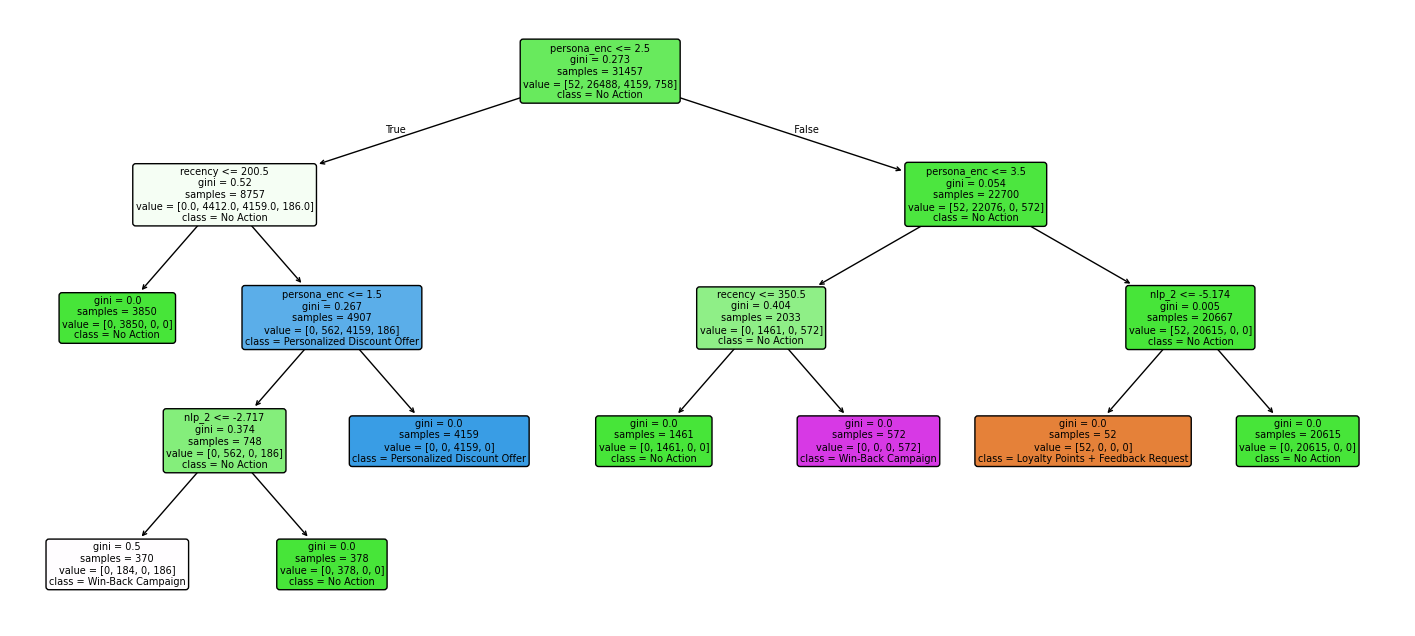

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=features,
    class_names=action_encoder.classes_,
    filled=True,
    rounded=True
)
plt.show()

In [9]:
for action_id, label in enumerate(action_encoder.classes_):
    print(f"{action_id} → {label}")

0 → Loyalty Points + Feedback Request
1 → No Action
2 → Personalized Discount Offer
3 → Win-Back Campaign


In [10]:
sample = data.sample(5, random_state=42)

sample[[
    "customer_unique_id",
    "persona",
    "recency",
    "nlp_2",
    "agent_action"
]]

,customer_unique_id,persona,recency,nlp_2,agent_action
16818,6d30fb7a44f6405e3df4ec6a5a1c787c,Silent Loyal Customers,330,-2.075334,No Action
31197,ca5c22758e4f6781ba277d327fe3d7eb,Silent Loyal Customers,318,-0.331852,No Action
30098,c318a0566b2a3b77d1f05bac5e8b4bea,Emerging Loyalists,72,-1.943184,No Action
10591,44a575d55982c95a7f09b62c7702bddc,High-Value Enthusiasts,294,5.293565,No Action
18111,7542698921c5856de2ce737b2f0b57d8,Emerging Loyalists,355,-2.137897,Personalized Discount Offer
